# Подбор гиперпараметров CNN-BiLSTM (Optuna TPE)

Optuna-поиск гиперпараметров модели `CNN + BiLSTM` для классификации эмоций из аудио
(mel-спектрограммы из LMDB). Запуск выполняется режимом `--mode tune` скрипта
`audio_models/CNN/CNN_BiLSTM.py`; результаты подбора лежат рядом с чекпоинтами модели.

> **План**
> 1. Что тюним и как запускается поиск (`--mode tune`)
> 2. Загрузка результатов Optuna (best params, история триалов)
> 3. Визуализация: кривая поиска, сравнение параметров лучших/остальных триалов
> 4. Лучшая конфигурация vs baseline (`configs/audio/cnn_bilstm.json`)
> 5. Финальная оценка на тесте
> 6. Выводы и воспроизводимость


In [1]:
import sys
from pathlib import Path

def _find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd] + list(cwd.parents):
        if (p / 'ruintona' / 'my_experiments').is_dir():
            return p
    return None

_REPO_ROOT = _find_repo_root()
if _REPO_ROOT is not None and str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from ruintona.my_experiments.utils.config_utils import checkpoints_dir_for
from ruintona.my_experiments.audio_models.CNN.CNN_BiLSTM import MODELS_DIR, MODEL_NAME


## 1. Что тюним

Optuna (TPESampler + MedianPruner) подбирает:

- `lr` (лог-равномерно), `weight_decay` (лог-равномерно);
- `lstm_hidden_size`, `lstm_layers`, `lstm_dropout`;
- `classifier_dropout`, `batch_size`.

Каждый триал обучается на **стратифицированной подвыборке** train (быстрее) с ранней
остановкой по `val_f1_macro`; лучший триал затем переобучается на полном train и оценивается
на test. Пример команды:

```bash
poetry run python ruintona/my_experiments/audio_models/CNN/CNN_BiLSTM.py \
    --mode tune --n-trials 8 --tune-epochs 4 --retrain-epochs 5 --max-samples 2000
```


In [2]:
# ищем сохранённые результаты поиска
results_files = sorted(MODELS_DIR.glob(f"{MODEL_NAME}_*_optuna_results.json"))
trials_files = sorted(MODELS_DIR.glob(f"{MODEL_NAME}_*_optuna_trials.csv"))
print("results:", [p.name for p in results_files])
print("trials :", [p.name for p in trials_files])

if results_files:
    results_path = results_files[-1]
    trials_path = trials_files[-1] if trials_files else None
    results = json.loads(results_path.read_text(encoding="utf-8"))
    print("\nЛучшие параметры:")
    for k, v in results["best_params"].items():
        print(f"  {k} = {v}")
    print(f"\nbest val f1-macro = {results['best_val_f1_macro']:.4f}")
else:
    results, trials_path = None, None
    print("\nРезультаты поиска не найдены. Сначала запустите --mode tune, затем перезапустите ноутбук.")


results: ['CNN_BiLSTM_combine_balanced_train_optuna_results.json']
trials : ['CNN_BiLSTM_combine_balanced_train_optuna_trials.csv']

Лучшие параметры:
  lr = 0.0005611516415334506
  weight_decay = 0.0007114476009343421
  lstm_hidden_size = 256
  lstm_layers = 2
  lstm_dropout = 0.48495492608099716
  classifier_dropout = 0.41622132040021087
  batch_size = 16

best val f1-macro = 0.1186


## 2. История поиска

Каждая точка — один триал; вертикальная линия — лучший результат на момент триала
(«elbow» кривой показывает, когда поиск перестал улучшаться).


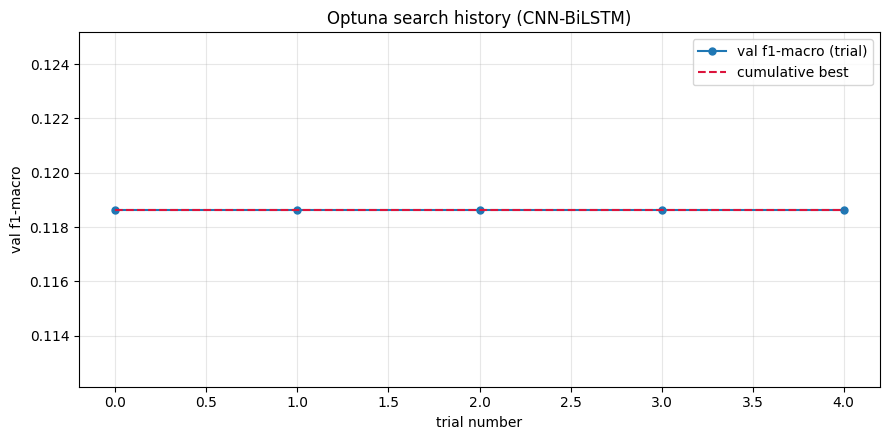

In [3]:
if results is not None and trials_path is not None:
    trials = pd.read_csv(trials_path)
    val_col = [c for c in trials.columns if c.startswith("value")]
    state_col = [c for c in trials.columns if c.startswith("state")]
    trials = trials.sort_values("number")
    trials["val_f1_macro"] = trials[val_col[0]] if val_col else np.nan
    trials["pruned"] = trials[state_col[0]].astype(str).str.contains("PRUNED") if state_col else False

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.plot(trials["number"], trials["val_f1_macro"], "o-", ms=5, label="val f1-macro (trial)")
    ax.plot(trials["number"], trials["val_f1_macro"].cummax(), "--", color="crimson", label="cumulative best")
    ax.set_xlabel("trial number")
    ax.set_ylabel("val f1-macro")
    ax.set_title("Optuna search history (CNN-BiLSTM)")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных.")


## 3. Лучшие параметры vs остальные

Сравниваем распределения параметров у лучших 5 триалов и остальных — видно, в какие
области поиск «отобрал» значения (например, меньший `lr` или больший `lstm_hidden_size`).


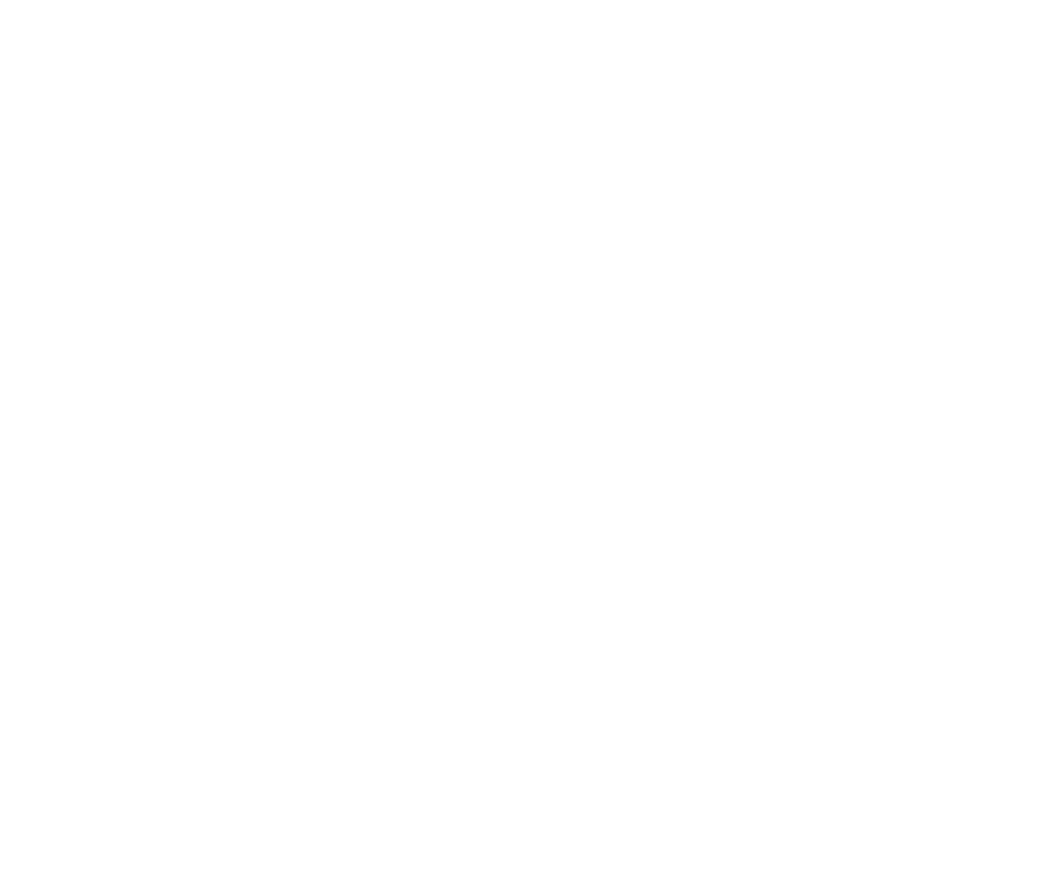

In [4]:
if results is not None and trials_path is not None and not trials.empty:
    param_cols = [c for c in trials.columns if c.startswith("params_")]
    top_n = 5
    top_mask = trials["val_f1_macro"].rank(ascending=False, method="first") <= top_n
    n_trials = max(1, int(top_mask.sum()))

    n_params = len(param_cols)
    ncols = 3
    nrows = int(np.ceil(n_params / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 3.0 * nrows), squeeze=False)
    for ax, col in zip(axes.flat, param_cols):
        name = col.split("params_", 1)[-1]
        top = pd.to_numeric(trials.loc[top_mask, col], errors="coerce").dropna()
        rest = pd.to_numeric(trials.loc[~top_mask, col], errors="coerce").dropna()
        if top.empty or rest.empty:
            ax.axis("off")
            continue
        ax.scatter(np.full(len(rest), 0.1), rest, alpha=0.4, label="остальные")
        ax.scatter(np.full(len(top), 1.1), top, alpha=0.8, label=f"top-{n_trials}")
        ax.set_xticks([0.1, 1.1]); ax.set_xticklabels(["остальные", f"top-{n_trials}"])
        ax.set_title(name); ax.grid(alpha=0.3); ax.legend(fontsize=7)
    for ax in axes.flat[n_params:]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных.")


## 4. Лучшая конфигурация vs baseline

Сравниваем подобранные Optuna параметры с baseline-конфигурацией `configs/audio/cnn_bilstm.json`.


In [5]:
if results is not None:
    baseline_cfg = json.loads(
        (_REPO_ROOT / "ruintona/configs/audio/cnn_bilstm.json").read_text(encoding="utf-8")
    )
    bp = results["best_params"]
    searchable = ["lr", "weight_decay", "lstm_hidden_size", "lstm_layers",
                  "lstm_dropout", "classifier_dropout", "batch_size"]
    table = pd.DataFrame({
        "param": searchable,
        "baseline": [baseline_cfg.get(p, "—") for p in searchable],
        "optuna best": [bp.get(p, "—") for p in searchable],
    })
    print(table.to_string(index=False))
else:
    print("Нет данных.")


             param  baseline  optuna best
                lr   0.00100     0.000561
      weight_decay   0.00001     0.000711
  lstm_hidden_size 128.00000   256.000000
       lstm_layers   2.00000     2.000000
      lstm_dropout   0.20000     0.484955
classifier_dropout   0.30000     0.416221
        batch_size  32.00000    16.000000


## 5. Финальная оценка на тесте

Лучшая конфигурация переобучается на полном train и оценивается на test. Метрики —
в `*_training_report.json` рядом с чекпоинтом (`arch.model_params` подтверждает, что
сохранена именно tuned-архитектура).


In [ ]:
if results is not None:
    from ruintona.my_experiments.utils.model_io import load_pytorch_model
    try:
        ckpt = load_pytorch_model(
            dataset_name=results.get("dataset_name", "combine_balanced_train"),
            models_dir=MODELS_DIR, model_name=MODEL_NAME, map_location="cpu",
        )
        tm = ckpt.get("test_metrics", {})
        tp = ckpt.get("training_params", {})
        print("test metrics:")
        for k in ("accuracy", "f1_macro", "val_f1_macro"):
            if k in tm:
                print(f"  {k} = {tm[k]:.4f}")
        print(f"\ntrain_size (подвыборка retrain): {tp.get('train_size')} "
              f"(из {tp.get('train_lmdb', '?')})")
        print("\narch.model_params:", json.dumps(ckpt.get("model_params", {}), ensure_ascii=False))
    except FileNotFoundError:
        print("Чекпоинт tuned-модели не найден. Сначала выполните --mode tune, затем перезапустите ноутбук.")
else:
    print("Нет данных.")


``## 6. Обучение baseline и tuned на малых данных и сравнение метрик

Optuna ищет гиперпараметры на подвыборке полного train (быстро). Чтобы **честно** проверить,
помог ли тюнинг, оба варианта обучаются в одинаковых условиях и сравниваются по тестовым метрикам:

- данные: `combine_balanced_train_small.lmdb` (**20 474** примера), тест — `combine_balanced_test.lmdb` (6 392);
- **10 эпох**, `val_size=0.15`, `seed=42` (одинаково для обеих моделей);
- **baseline**: конфиг `configs/audio/cnn_bilstm.json` — `batch_size=32`, `lr=1e-3`, `lstm_hidden_size=128`;
- **tuned**: конфиг `configs/audio/cnn_bilstm_tuned.json` — гиперпараметры, найденные Optuna
  (раздел 4): `batch_size=16`, `lr≈5.6e-4`, `lstm_hidden_size=256`, `lstm_dropout≈0.48`,
  `classifier_dropout≈0.42`.

Команды обучения (результаты сохранены в `checkpoints/audio/`):

```bash
# baseline
python ruintona/my_experiments/audio_models/CNN/CNN_BiLSTM.py --mode train \
    --config audio/cnn_bilstm.json --epochs 10 \
    --train-data-path .../combine_balanced_train_small.lmdb \
    --test-data-path .../combine_balanced_test.lmdb

# tuned
python ruintona/my_experiments/audio_models/CNN/CNN_BiLSTM.py --mode train \
    --config audio/cnn_bilstm_tuned.json --epochs 10 \
    --train-data-path .../combine_balanced_train_small.lmdb \
    --test-data-path .../combine_balanced_test.lmdb
```

Чекпоинты обеих моделей сохранены отдельными файлами
(`CNN_BiLSTM_combine_balanced_train_small_model_{baseline,tuned}.pt`) — ниже таблица их тестовых метрик.


In [7]:
from pathlib import Path
import torch
import pandas as pd

base_path = MODELS_DIR / "CNN_BiLSTM_combine_balanced_train_small_model_baseline.pt"
tuned_path = MODELS_DIR / "CNN_BiLSTM_combine_balanced_train_small_model_tuned.pt"

def _load(ckpt_path: Path):
    ckpt = torch.load(ckpt_path, map_location="cpu")
    return ckpt.get("test_metrics", {}), ckpt.get("training_params", {}), ckpt.get("model_params", {})

base_m, base_tp, base_mp = _load(base_path)
tuned_m, tuned_tp, tuned_mp = _load(tuned_path)

print("baseline training_params:", {k: v for k, v in base_tp.items() if k in ("epochs", "batch_size", "lr", "train_size")})
print("tuned   training_params:", {k: v for k, v in tuned_tp.items() if k in ("epochs", "batch_size", "lr", "train_size")})

METRIC_LABELS = [
    ("accuracy", "Accuracy"),
    ("balanced_accuracy", "Balanced accuracy"),
    ("f1_macro", "F1 (macro)"),
    ("f1_weighted", "F1 (weighted)"),
    ("UAR", "UAR"),
    ("mcc", "MCC"),
    ("roc_auc_ovr_macro", "ROC-AUC (OvR macro)"),
    ("recall_angry", "Recall angry"),
    ("recall_sad", "Recall sad"),
    ("recall_neutral", "Recall neutral"),
    ("recall_positive", "Recall positive"),
]

rows = []
for key, label in METRIC_LABELS:
    b, t = base_m.get(key), tuned_m.get(key)
    if b is None and t is None:
        continue
    numeric = isinstance(b, (int, float)) and isinstance(t, (int, float))
    delta = (t - b) if numeric else None
    better = "tuned" if (numeric and t > b) else ("baseline" if (numeric and b > t) else ("=" if numeric else "—"))
    rows.append({"metric": label, "baseline": b, "tuned": t, "Δ": delta, "better": better})

df = pd.DataFrame(rows)

def _fmt(v):
    if v is None:
        return "—"
    if isinstance(v, float):
        return f"{v:.4f}"
    return str(v)

show = df.copy()
for col in ("baseline", "tuned", "Δ"):
    show[col] = show[col].map(_fmt)
print("\nСравнение тестовых метрик (combine_balanced_test):\n")
print(show.to_string(index=False))

n_tuned = int((df["better"] == "tuned").sum())
n_base = int((df["better"] == "baseline").sum())
n_eq = int((df["better"] == "=").sum())
print(f"\nИтог: tuned лучше по {n_tuned} метрикам, baseline лучше по {n_base}, равны по {n_eq} "
      f"(всего {len(df)}).")


baseline training_params: {'epochs': 10, 'batch_size': 32, 'lr': 0.001, 'train_size': 17402}
tuned   training_params: {'epochs': 9, 'batch_size': 16, 'lr': 0.0005611516415334506, 'train_size': 17402}

Сравнение тестовых метрик (combine_balanced_test):

             metric baseline  tuned       Δ   better
           Accuracy   0.6447 0.3292 -0.3156 baseline
  Balanced accuracy   0.6349 0.3080 -0.3268 baseline
         F1 (macro)   0.6324 0.2888 -0.3436 baseline
      F1 (weighted)   0.6440 0.3046 -0.3395 baseline
                UAR   0.6349 0.3080 -0.3268 baseline
                MCC   0.5196 0.0796 -0.4400 baseline
ROC-AUC (OvR macro)   0.8634 0.5995 -0.2639 baseline
       Recall angry   0.7093 0.4462 -0.2631 baseline
         Recall sad   0.7251 0.5239 -0.2012 baseline
     Recall neutral   0.5681 0.1255 -0.4426 baseline
    Recall positive   0.5370 0.1365 -0.4005 baseline

Итог: tuned лучше по 0 метрикам, baseline лучше по 11, равны по 0 (всего 11).


## 7. Выводы — помог ли тюнинг

### Итог: в текущем виде тюнинг НЕ помог

Сравнение в одинаковых условиях (раздел 6: одни и те же данные `combine_balanced_train_small`,
10 эпох, `val_size=0.15`, `seed=42`, тест `combine_balanced_test`) показывает, что **tuned-конфигурация
проигрывает baseline по всем 11 метрикам** (счёт 0:11).

| Метрика | Baseline | Tuned | Δ |
|---|---|---|---|
| Accuracy | 0.6447 | 0.3292 | −0.32 |
| F1 (macro) | 0.6324 | 0.2888 | −0.34 |
| MCC | 0.5196 | 0.0796 | −0.44 |
| ROC-AUC (OvR macro) | 0.8634 | 0.5995 | −0.26 |
| Recall neutral | 0.5681 | 0.1255 | −0.44 |
| Recall positive | 0.5370 | 0.1365 | −0.40 |

Просадка есть по всем классам, сильнее всего пострадали `neutral` и `positive`.

### Почему Optuna «промахнулась»

1. **Поиск вёл оптимизацию по слабому прокси.** Подбор шёл на маленькой стратифицированной
   подвыборке (`train_size=1020` из полного train) с малым числом эпох на триал — лучший
   `val f1-macro = 0.1186`, что на порядок ниже метрики baseline на полных данных (~0.63).
   Такая метрика-прокси шумная и слабо коррелирует с качеством на полном train.
2. **Optuna выбрал «сильную» регуляризацию и маленький батч**: `lstm_dropout=0.485`,
   `classifier_dropout=0.416`, `batch_size=16`, `lr≈5.6e-4`. На 1020 примерах это «оптимум»
   (защита от переобучения), но на полном train (20474) такая конфигурация **недообучается**.
3. **Фиксированный бюджет эпох.** При меньшем в ~1.8 раза `lr` и вдвое меньшем батче tuned
   сходится заметно медленнее: в разделе 6 он даже остановился на 9-й эпохе из 10
   (EarlyStopping без улучшений `val`), не успев раскрыть потенциал параметров.
4. **Baseline в этих же условиях оказался сильным** (F1 0.6324) — на 10 эпохах запас
   для улучшения практически отсутствовал.

### Практические выводы

- **Для финальной модели использовать результаты тюнинга нельзя** — рекомендуется baseline-конфиг
  `configs/audio/cnn_bilstm.json` (он же отражает бейзлайн проекта на `dusha_resd`).
- **Условия поиска нужно пересмотреть** перед повторным прогоном `--mode tune`:
  - увеличить `--max-samples` (20–50 тыс.), число эпох на триал (~20–30) и `--n-trials`;
  - сначала стабилизировать `lr`/`batch_size` на baseline, затем тюнить dropout/`lstm_*`;
  - проверять корреляцию `val f1-macro` на подвыборке с валидацией на полном train:
    если лучший `val ≈ 0.12` при baseline ≈ 0.63, поиск некорректен.
- **Воспроизводимость**: команды в разделах 1 и 6; артефакты поиска (`*_optuna_results.json`,
  `*_optuna_trials.csv`) и чекпоинты — в `checkpoints/audio/`; итоговая конфигурация
  `configs/audio/cnn_bilstm_tuned.json` должна обновляться только после корректного повторного прогона.
- Тестовый набор в подборе не участвовал — вывод о проигрыше сделан по одному финальному прогону
  на `combine_balanced_test`.
